In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [6]:
df = pd.read_csv('social_media.csv')

In [7]:
df.head()

,user_name,follows_who,days
0,Anne,Carmen,200
1,Betty,Carmen,20
2,Carmen,Dillan,30
3,Jessica,Carmen,100
4,Dillan,Carmen,50


In [9]:
G1 = nx.DiGraph()

G1.add_node(1)
G1.add_node(2)
G1.add_node(3)
G1.add_node(4)
G1.add_node(5)

G1.add_edge(1, 2)
G1.add_edge(1, 3)
G1.add_edge(1, 4)
G1.add_edge(5, 4)
G1.add_edge(1, 5)

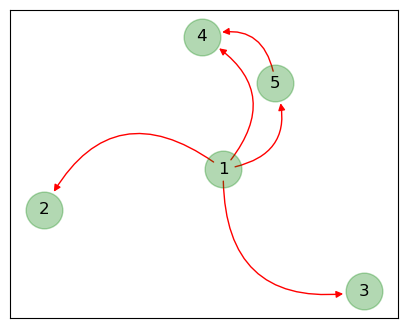

In [34]:
plt.figure(figsize = (5, 4))
pos = nx.spring_layout(G1)
nx.draw_networkx_nodes(G1,pos, node_color = 'green', alpha = 0.3, node_size = 700)
nx.draw_networkx_edges(G1, pos, edge_color = 'red', min_target_margin = 15, connectionstyle = 'arc3, rad = 0.6')
nx.draw_networkx_labels(G1, pos)
plt.show()

In [51]:
G = nx.DiGraph()

G.add_node('a')
G.add_node('b')
G.add_node(6)

G.add_edge('a', 'b')
G.add_edge('a', 6)
G.add_edge('b', 6)

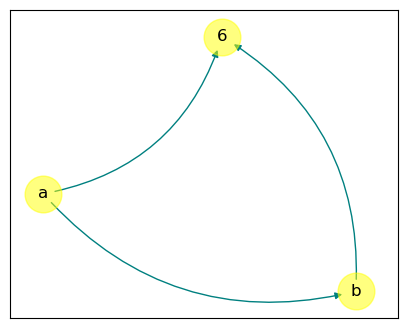

In [52]:
plt.figure(figsize = (5, 4))
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, node_color = 'yellow', alpha = 0.5, node_size = 700)
nx.draw_networkx_edges(G, pos, edge_color = 'teal', min_target_margin = 10, connectionstyle = 'arc3, rad = 0.3')
nx.draw_networkx_labels(G, pos)
plt.show()

In [57]:
G2 = nx.DiGraph()

G2.add_node('Nove')
G2.add_node('CP')
G2.add_node('D6')
G2.add_node('PR_001')

G2.add_edge('Nove', 'CP')
G2.add_edge('Nove', 'D6')
G2.add_edge('D6', 'PR_001')
G2.add_edge('PR_001', 'CP')
G2.add_edge('PR_001', 'Nove')

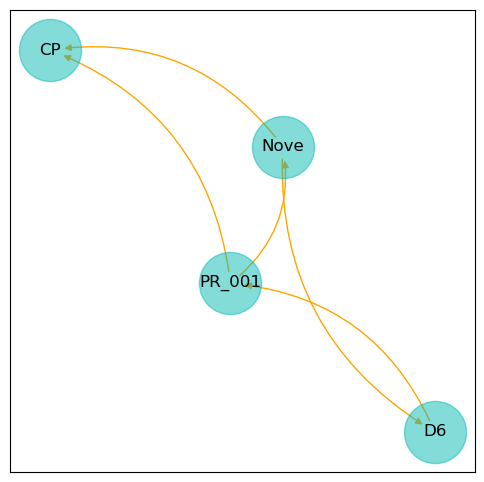

In [62]:
plt.figure(figsize = (6, 6))
pos = nx.spring_layout(G2)
nx.draw_networkx_nodes(G2, pos, node_color = '#0ABAB5', alpha = 0.5, node_size = 2000)
nx.draw_networkx_edges(G2, pos, edge_color = 'orange', min_target_margin = 10, connectionstyle = 'arc3, rad = 0.3')
nx.draw_networkx_labels(G2, pos)
plt.show()

In [63]:
G3 = nx.DiGraph()

In [93]:
df.head()

,user_name,follows_who,days
0,Anne,Carmen,200
1,Betty,Carmen,20
2,Carmen,Dillan,30
3,Jessica,Carmen,100
4,Dillan,Carmen,50


In [94]:
G3 = nx.from_pandas_edgelist(df, source = 'user_name', target = 'follows_who', edge_attr = 'days')
nodelist = G3.nodes()
print(nodelist)

['Anne', 'Carmen', 'Betty', 'Dillan', 'Jessica', 'Keth']


In [95]:
degree_info = nx.degree(G3)
print(degree_info)

[('Anne', 2), ('Carmen', 4), ('Betty', 1), ('Dillan', 3), ('Jessica', 1), ('Keth', 1)]


In [96]:
weights = list(nx.get_edge_attributes(G3, 'days').values())
weights = [i/50 for i in weights]
weights

[4.0, 0.6, 0.4, 1.0, 2.0, 2.0]

In [97]:
degree_values = [number*300 for user, number in degree_info]
degree_values

[600, 1200, 300, 900, 300, 300]

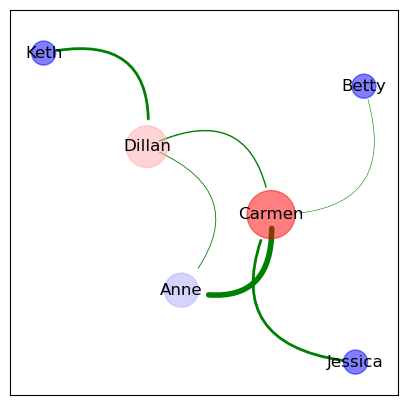

In [98]:
plt.figure(figsize = (5, 5))
pos_G3 = nx.spring_layout(G3)
nx.draw_networkx_nodes(G3, pos_G3, cmap = 'bwr', node_color = degree_values, alpha = 0.5, node_size = degree_values)
nx.draw_networkx_edges(G3, pos_G3, width = weights, edge_color = 'green', min_target_margin = 10,
                       min_source_margin = 20, connectionstyle = 'arc3, rad = 0.7', arrows = True)
nx.draw_networkx_labels(G3, pos_G3)
plt.show()